# ARIMA - Média Móvel Integrada AutoRegressiva para Análise de mercado de Commodities

## O que é ARIMA?
### Técnica para análise de séries temporais estacionárias e forecasting 

A técnica é a integração de 2 abordagens, modelagem por autoregressão e de médias móveis. Sendo que, é necessária uma base histórica robusta para o modelo funcionar, igual a todos os métodos de forecasting. 

> ##### O ARIMA é usado de 2 formas diferentes: 
> * **Não Sazonal:** não é aplicada a contabilização de sazonalidade, a previsão é baseada somente em padrões vistos nos dados passados
> * **Sazonal:** os ciclos regulares que afetam as séries temporais são levados em conta, sendo os ciclos semanais, mensais, etc. 

Uma série temporal é uma sequência ordenada de medições de uma variável em intervalos de tempo igualmente espaçados, nesse caso serão usados dados em Painel, já que vamos utilizar de dados econômicos em sequência.

#### **Caractéristicas dos dados das séries temporais**

Séries temporais podem ser estacionárias ou não estacionárias. Se uma série temporal é estacionária, ela possui propriedades estatísticas constantes ao longo do tempo, como exemplo: média, variância, autocorrelação. Pelo método de Box-Jenkins, é possível tentar aproximar uma série não-estacionária para uma estacionária. Métodos estatísticos, como o ARIMA, se baseiam na suposição que uma série pode se transformar em uma aproximadamente estacionária, já que é muito mais fácil prever algo que é aproximadamente igual no futuro. 

# Autocorrelação 

Métrica utilizada em uma série temporal está correlacionada com o passado. Ajuda a dar uma noção de que tipo de modelo pode representar melhor os dados.

$$r_K = \frac{\sum_{t=K+1}^T (y_t -\bar{y}) - (y_t - K - \bar{y})}{\sum_{t=1}^T (y_t - \bar{y})²}$$

* r é qualquer defasagem na autocorrelação
* T é o comprimento da série temporal
* y é o valor da série
* Os coeficientes de autocorrelação compõem a *função de autocorrelação*

# Metodologia da Análise 

**Objetivo:** analise o comportamento histórico de como as sementes forrageiras no mercado afetam os valores dos produtos de consumo, como as principais commodities do mercado (milho, soja e trigo) e o mercado do agronegócio (bovinos) usando a série mensal do World Bank Pink Sheet (2007-presente). 

**Metodologia**: esse trabalho se baseou e adaptou o *Zherlitsyn et al., 2025, Econometrics 13(4), 52* (ver referência completa no final):

1. Coleta e diagnóstico de dados (estatística descritiva + teste de estacionariedade ADF)
2. Matriz de correlação entre commodities (nível e com defasagem/lag)
3. Desvio em relação à média histórica (z-score) — indicador de "caro vs. barato"
4. Modelo ARIMA baseline por commodity, com backtest simples (MAPE)

O paper de referência mostrou que, em séries mensais de commodities agrícolas (volatilidade baixa-média), o ARIMA baseline tem desempenho equivalente ou superior a modelos de Machine Learning mais complexos, por isso só este notebook irá aplicar só o ARIMA, sem componentes de ML. 


## Setup e Coleta 

**Fonte:** **World Bank Commodity Markets ("Pink Sheet")** — arquivo mensal público, atualizado
mensalmente pelo próprio World Bank.

Extraímos as séries temporais das commodities em US$/mt (dólares por tonelada métrica) e carne bovina em US$/kg (dólar por quilograma)

> Para harmonizar a base de dados de forma a conseguir comparar os valores entre quilogramas e toneladas, aplica-se a conversão escalar na cotação do bovino:
> $$\text{Preço}_{\text{Bovinos } (\text{US}\$/\text{mt})} = \text{Preço}_{\text{Bovinos } (\text{US}\$/\text{kg})} \times 1.000$$
> **Nota Metodológica:** Esta transformação linear de escala preserva integralmente as propriedades estatísticas da série (autocorrelação, estacionariedade, taxas de variação e Z-scores), garantindo a integridade do diagnóstico e das previsões dos modelos ARIMA.

In [34]:
import pandas as pd
import numpy as np
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [20]:
# Setando parâmetros 

URL_WORLD_BANK = (
    "https://thedocs.worldbank.org/en/doc/"
    "74e8be41ceb20fa0da750cda2f6b9e4e-0050012026/related/"
    "CMO-Historical-Data-Monthly.xlsx"
)

WB_COLUNAS = {
    "Milho": "Maize",
    "Soja":  "Soybeans",
    "Trigo": "Wheat, US HRW",
    "Bovinos": "Beef **",
    "Frangos": "Chicken **",
    "Cordeiros": "Lamb **"
    }

DATA_INICIO = "2000-1-1"

In [21]:
# Função para buscar os dados do World Bank

def buscar_world_bank():
    resp = requests.get(URL_WORLD_BANK, timeout=60)
    resp.raise_for_status()
    arquivo = BytesIO(resp.content)

    df_puro = pd.read_excel(
        arquivo, sheet_name="Monthly Prices", header=4, skiprows=[5],
        index_col=0, na_values=["…", "..", "..."]
    )

    colunas_usar = {nome: col for nome, col in WB_COLUNAS.items() if col in df_puro.columns}
    df = df_puro[list(colunas_usar.values())].copy()
    df.columns = list(colunas_usar.keys())

    datas_str = df.index.astype(str).str.replace("M", "-", regex=False)
    df.index = pd.to_datetime(datas_str, format="%Y-%m", errors="coerce")
    df = df[df.index.notna()]
    df = df[df.index >= pd.to_datetime(DATA_INICIO)]
    df = df.apply(pd.to_numeric, errors="coerce").dropna(how="all")

    return df

# Check up das informações adquiridas 
df_commodities = buscar_world_bank()

# Frango, Cordeiro e Boi vêm em US$/kg — converte para US$/mt (mesma unidade dos grãos)
for col in ["Bovinos", "Frangos", "Cordeiros"]:
    df_commodities[col] = df_commodities[col] * 1000

print(df_commodities[["Bovinos", "Frangos", "Cordeiros"]].describe())

print(f"Período: {df_commodities.index.min():%Y-%m} até {df_commodities.index.max():%Y-%m}")
print(f"Total de Observações: {len(df_commodities)}")
df_commodities.tail()

           Bovinos      Frangos     Cordeiros
count   319.000000   319.000000    319.000000
mean   3978.244514  1787.210031   6083.354232
std    1444.266279   304.022389   2044.569053
min    1810.000000  1260.000000   2480.000000
25%    2700.000000  1530.000000   4305.000000
50%    4100.000000  1780.000000   6270.000000
75%    4715.000000  1970.000000   7770.000000
max    8210.000000  2720.000000  10280.000000
Período: 2000-01 até 2026-07
Total de Observações: 319


,Milho,Soja,Trigo,Bovinos,Frangos,Cordeiros
2026-03-01,212.7,473,276.0,8210.0,1660.0,6540.0
2026-04-01,214.0,463,282.0,8210.0,1750.0,7110.0
2026-05-01,216.2,473,303.0,7950.0,1860.0,7280.0
2026-06-01,197.1,464,286.0,7460.0,1770.0,7470.0
2026-07-01,213.4,459,310.0,7310.0,1730.0,7590.0


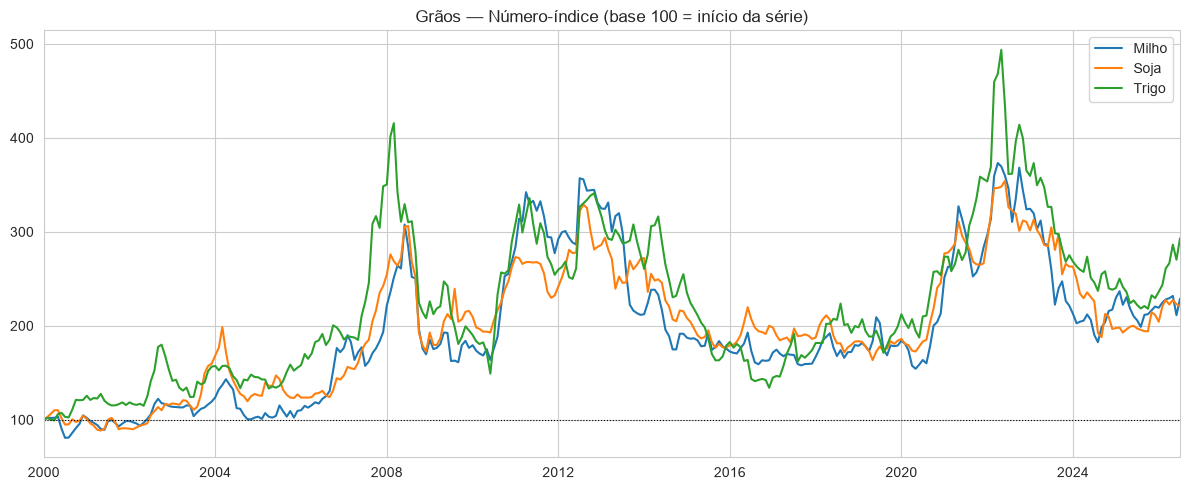

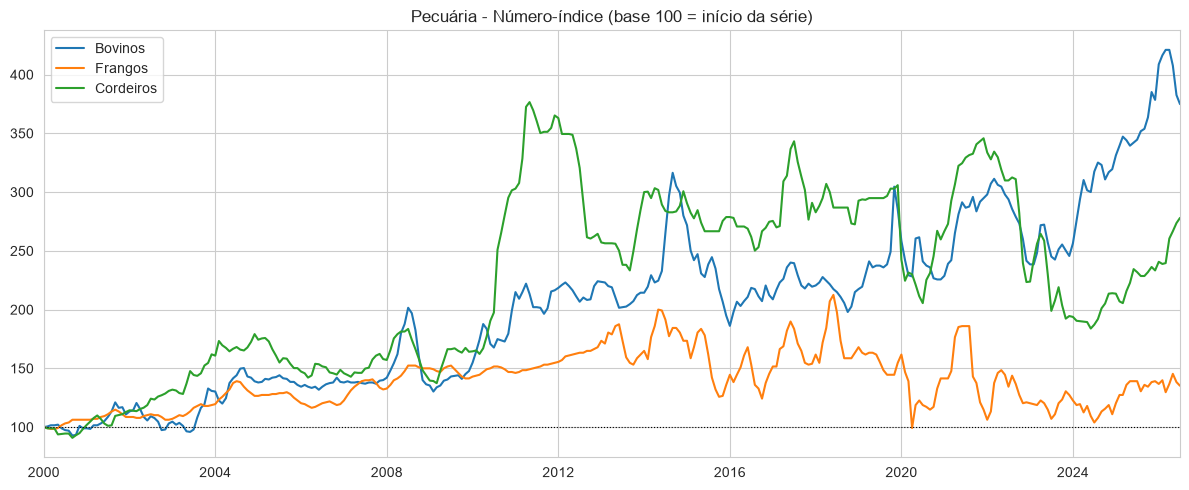

In [22]:
# Gráficos por categorias 

categoria_graos = ["Milho", "Soja", "Trigo"]
categoria_pecuaria = ["Bovinos", "Frangos", "Cordeiros"]

# Gráfico 1: Grãos 
df_indexado_graos = (df_commodities[categoria_graos] / df_commodities[categoria_graos].iloc[0]) * 100
fig, ax = plt.subplots(figsize=(12, 5))
for col in df_indexado_graos.columns:
    ax.plot(df_indexado_graos.index, df_indexado_graos[col], label=col)
ax.axhline(100, color="black", linewidth=0.8, linestyle=":")
ax.set_title("Grãos — Número-índice (base 100 = início da série)")
ax.legend()
plt.margins(x=0)
plt.tight_layout()
plt.show()

# Gráfico 2: Pecuária
df_indexado_pecuaria = (df_commodities[categoria_pecuaria] / df_commodities[categoria_pecuaria].iloc[0]) * 100
fig, ax = plt.subplots(figsize=(12, 5))
for col in df_indexado_pecuaria.columns:
    ax.plot(df_indexado_pecuaria.index, df_indexado_pecuaria[col], label=col)
ax.axhline(100, color="black", linewidth=0.8, linestyle=":")
ax.set_title("Pecuária - Número-índice (base 100 = início da série)")
ax.legend()
plt.margins(x=0)
plt.tight_layout()
plt.show()

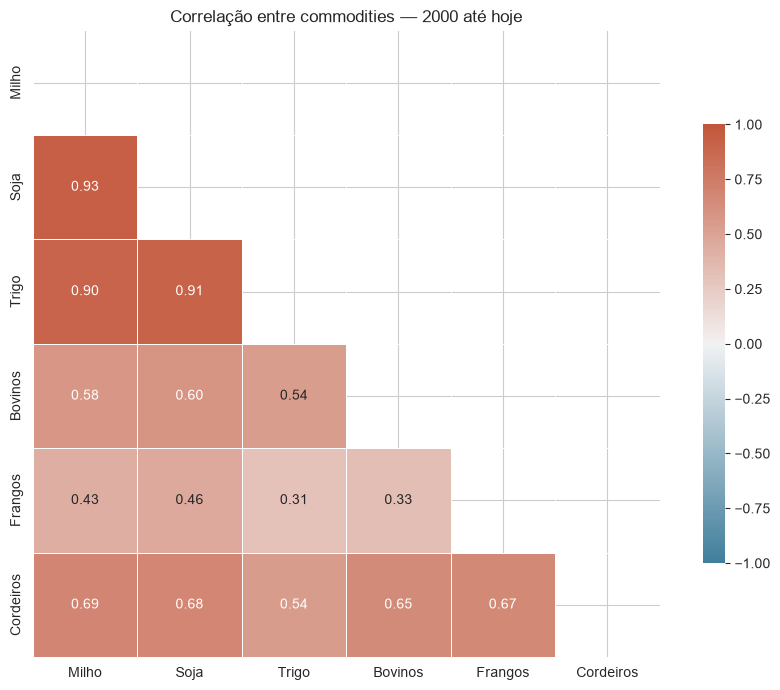

In [23]:
corr_commodities = df_commodities.corr()

mask = np.triu(np.ones_like(corr_commodities, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_commodities, mask=mask, cmap=cmap,
    vmin=-1, vmax=1, center=0,       # <- corrigido: escala real de correlação
    annot=True, fmt=".2f",            # <- adicionado: mostra os valores
    square=True, linewidths=.5, cbar_kws={"shrink": .7}
)
ax.set_title("Correlação entre commodities — 2000 até hoje")
plt.tight_layout()
plt.show()

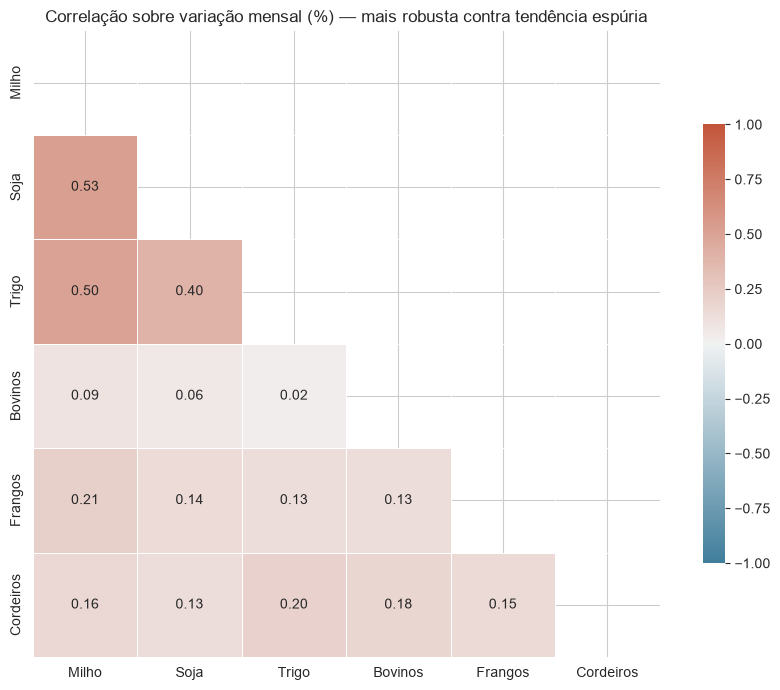

In [24]:
# Correlação sobre variação mensal (% change)
df_variacao = df_commodities.pct_change().dropna()
corr_variacao = df_variacao.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_variacao, mask=mask, cmap=cmap,
    vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f",
    square=True, linewidths=.5, cbar_kws={"shrink": .7}
)
ax.set_title("Correlação sobre variação mensal (%) — mais robusta contra tendência espúria")
plt.tight_layout()
plt.show()

In [25]:
def testar_estacionariedade(serie, nome):
    serie_limpa = serie.dropna()
    resultado_nivel = adfuller(serie_limpa)
    resultado_diff  = adfuller(serie_limpa.diff().dropna())

    return {
        "Commodity": nome,
        "Média (US$/mt)": round(serie_limpa.mean(), 2),
        "CV (Coef. Variação)": round(serie_limpa.std() / serie_limpa.mean(), 3),
        "ADF p-valor (nível)": round(resultado_nivel[1], 4),
        "Estacionária no nível?": "Sim" if resultado_nivel[1] < 0.05 else "Não",
        "ADF p-valor (diferenciada)": round(resultado_diff[1], 4),
        "d recomendado (ARIMA)": 0 if resultado_nivel[1] < 0.05 else 1,
    }

tabela_diagnostico = pd.DataFrame([
    testar_estacionariedade(df_commodities[col], col) for col in df_commodities.columns
])
tabela_diagnostico

,Commodity,Média (US$/mt),CV (Coef. Variação),ADF p-valor (nível),Estacionária no nível?,ADF p-valor (diferenciada),d recomendado (ARIMA)
0,Milho,181.55,0.374,0.1242,Não,0.0,1
1,Soja,415.38,0.319,0.1563,Não,0.0,1
2,Trigo,234.80,0.350,0.0835,Não,0.0,1
3,Bovinos,3978.24,0.363,0.9852,Não,0.0,1
4,Frangos,1787.21,0.170,0.1318,Não,0.0,1
5,Cordeiros,6083.35,0.336,0.2241,Não,0.0,1


# Z-Score 

Z-Score é uma medida simples utilizada para medir quantas variações um ponto está da média. 
$$ z_t = \frac{P_t - \bar{P}}{\sigma_P} $$

Sendo: 
- $P_t$: preço do mês t
- $\bar{P}$: média de toda a série histórica
- $\sigma_P$: desvio padrão de toda a série 

Sendo que: 
- |z| = 0 $\rightarrow$ ponto está exatamente na média
- |z| > 0 $\rightarrow$ acima da média
- |z| < 0 $\rightarrow$ abaixo da média

Para isso, será utilizado a biblioteca pandas e numpy, para analisar o mês mais recente da base de dados utilizada. 

In [26]:
df_zscores = df_commodities.apply(lambda x: (x - x.mean()) / x.std())

print(df_zscores.tail())

               Milho      Soja     Trigo   Bovinos   Frangos  Cordeiros
2026-03-01  0.458354  0.434563  0.501464  2.930038 -0.418423   0.223346
2026-04-01  0.477483  0.359145  0.574495  2.930038 -0.122392   0.502133
2026-05-01  0.509855  0.434563  0.830105  2.750016  0.239423   0.585280
2026-06-01  0.228808  0.366687  0.623183  2.410743 -0.056608   0.678209
2026-07-01  0.468654  0.328978  0.915308  2.306884 -0.188177   0.736901


Colocar análise do z-score  

# Correlação com lag (defasagem temporal)

Considerando o ciclo econômico de produção das commodities, as commodities agrícolas utilizadas para alimentar ou produzir rações específicas para as pecuárias. 

Assim, o ciclo de produção, seguindo o ecônomico, não tem correlação em tempo exato, assim para testar de modo melhor a correlação, testaremos usando um escopo de desafagem temporal para encontrar o ciclo em que melhor mostram a correlação entre as commodities. 

$$ R_{xy}(T) = \sum_t x(t)*y(t + T)$$

Sendo:
- $R_{xy}(T)$: correlação com defasagem de tempo T
- $x(t) e y(t)$: são as 2 séries temporais
- $T$ é a defasagem

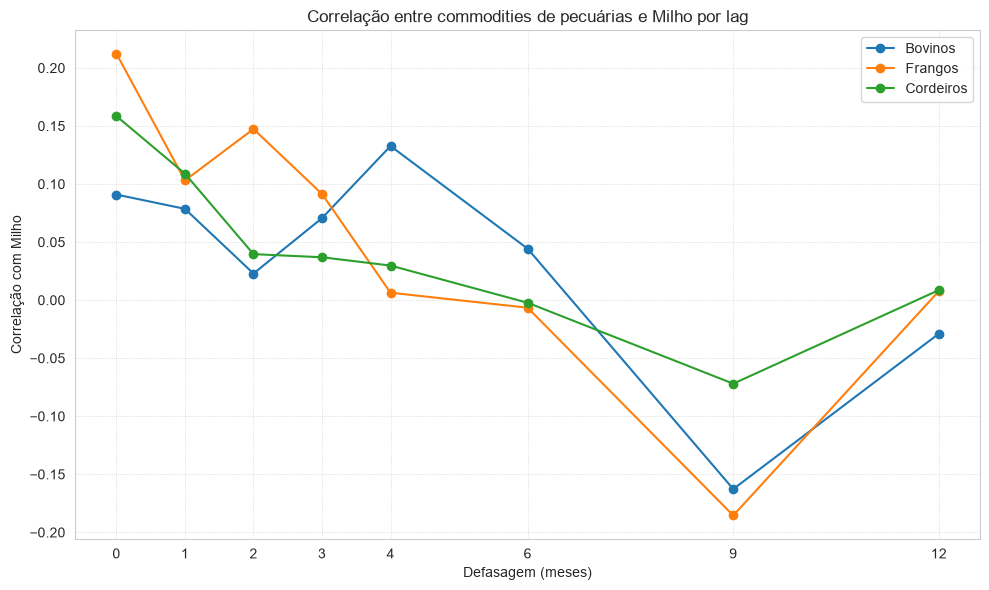

In [27]:
lag = [0, 1, 2, 3, 4, 6, 9, 12]

for i in lag:
    df_variacao[f"Milho_lag_{i}"] = df_variacao["Milho"].shift(i)

corr_lag = df_variacao[["Bovinos", "Frangos", "Cordeiros"] + [f"Milho_lag_{i}" for i in lag]].corr()

milho_lag_cols = [f"Milho_lag_{i}" for i in lag]

mask = np.zeros_like(corr_lag, dtype=bool)

corr_lag_milho = corr_lag.loc[["Bovinos", "Frangos", "Cordeiros"], milho_lag_cols].T
corr_lag_milho.index = lag

fig, ax = plt.subplots(figsize=(10, 6))
for commodity in corr_lag_milho.columns:
    ax.plot(corr_lag_milho.index, corr_lag_milho[commodity], marker="o", label=commodity)

ax.set_xticks(corr_lag_milho.index)
ax.set_xlabel("Defasagem (meses)")
ax.set_ylabel("Correlação com Milho")
ax.set_title("Correlação entre commodities de pecuárias e Milho por lag")
ax.legend()
ax.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()


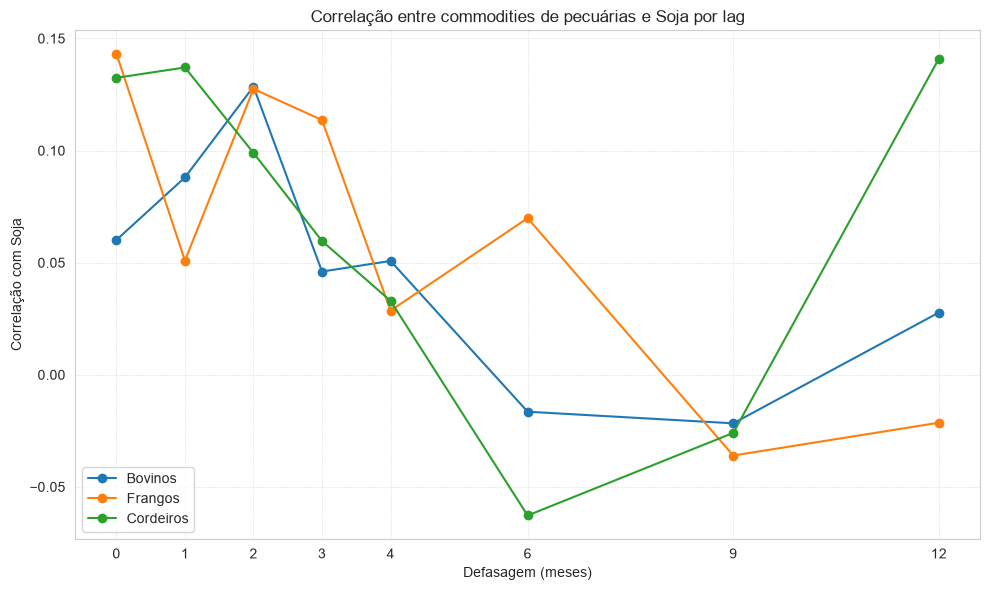

In [28]:
for i in lag:
    df_variacao[f"Soja_lag_{i}"] = df_variacao["Soja"].shift(i)

corr_lag_soja = df_variacao[["Bovinos", "Frangos", "Cordeiros"] + [f"Soja_lag_{i}" for i in lag]].corr()

soja_lag_cols = [f"Soja_lag_{i}" for i in lag]

corr_lag_soja_subset = corr_lag_soja.loc[["Bovinos", "Frangos", "Cordeiros"], soja_lag_cols].T
corr_lag_soja_subset.index = lag

fig, ax = plt.subplots(figsize=(10, 6))
for commodity in corr_lag_soja_subset.columns:
    ax.plot(corr_lag_soja_subset.index, corr_lag_soja_subset[commodity], marker="o", label=commodity)

ax.set_xticks(corr_lag_soja_subset.index)
ax.set_xlabel("Defasagem (meses)")
ax.set_ylabel("Correlação com Soja")
ax.set_title("Correlação entre commodities de pecuárias e Soja por lag")
ax.legend()
ax.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

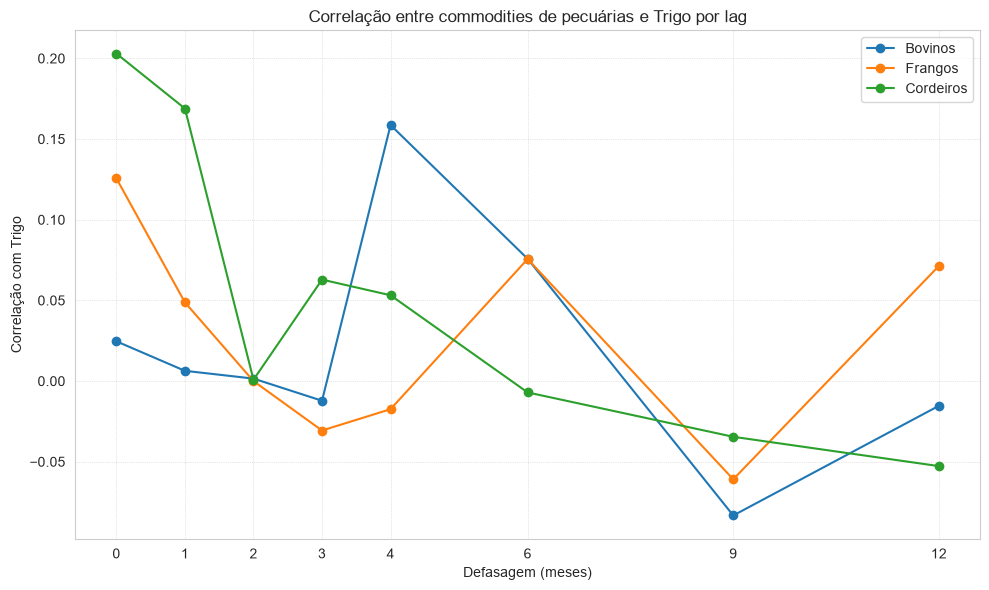

In [29]:
for i in lag:
    df_variacao[f"Trigo_lag_{i}"] = df_variacao["Trigo"].shift(i)

corr_lag_trigo = df_variacao[["Bovinos", "Frangos", "Cordeiros"] + [f"Trigo_lag_{i}" for i in lag]].corr()

trigo_lag_cols = [f"Trigo_lag_{i}" for i in lag]

corr_lag_trigo_subset = corr_lag_trigo.loc[["Bovinos", "Frangos", "Cordeiros"], trigo_lag_cols].T
corr_lag_trigo_subset.index = lag

fig, ax = plt.subplots(figsize=(10, 6))
for commodity in corr_lag_trigo_subset.columns:
    ax.plot(corr_lag_trigo_subset.index, corr_lag_trigo_subset[commodity], marker="o", label=commodity)

ax.set_xticks(corr_lag_trigo_subset.index)
ax.set_xlabel("Defasagem (meses)")
ax.set_ylabel("Correlação com Trigo")
ax.set_title("Correlação entre commodities de pecuárias e Trigo por lag")
ax.legend()
ax.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

# ADF - Augmented Dickey-Fuller

### O teste ADF é uma verificação estatística de estacionariedade em Séries Temporais

O teste de Dickey-Fuller Aumentado (ADF) é um teste de hipótese utilizado para identificar se uma série temporal possui uma "raiz unitária", o que é um forte indicativo de que ela é **não estacionária**.

Como estabelecido na técnica de Box-Jenkins, métodos estatísticos de previsão, como o ARIMA, exigem que a série trabalhada seja estacionária. Ou seja, ela deve possuir propriedades estatísticas constantes ao longo do tempo, como média e variância. O teste ADF é a ferramenta que fornece a prova matemática de que os dados atendem a esse requisito ou se precisam de tratamento prévio.

> ##### Como interpretar o resultado (P-valor):
> A decisão do teste baseia-se na análise do **p-valor**, adotando um nível de significância padrão de 5% (0,05):
> * **p-valor >= 0,05 (Não Estacionária):** A hipótese nula não é rejeitada. A série possui tendência ou ciclos atrelados ao tempo. É necessário aplicar a diferenciação nos dados (usar o parâmetro d > 0 no modelo ARIMA).
> * **p-valor < 0,05 (Estacionária):** A hipótese nula é rejeitada. A série tem comportamento estacionário e gravita em torno de uma média constante. Os dados já estão prontos para a modelagem (usar o parâmetro d = 0 no modelo ARIMA).

**Aplicação no Projeto:** Na nossa análise de commodities, o teste ADF diagnostica se podemos prever os preços diretamente no nível original ou se precisaremos trabalhar com as variações dos preços (série diferenciada) para garantir a integridade do modelo.

In [30]:
# Teste rápido 

for coluna in df_commodities.columns:
    serie = df_commodities[coluna].dropna()
    p_valor = adfuller(serie)[1]

    print(f"Commodity: {coluna} | p-valor ADF: {p_valor:.4f} | Estacionária? {'Sim' if p_valor < 0.05 else 'Não'}")

Commodity: Milho | p-valor ADF: 0.1242 | Estacionária? Não
Commodity: Soja | p-valor ADF: 0.1563 | Estacionária? Não
Commodity: Trigo | p-valor ADF: 0.0835 | Estacionária? Não
Commodity: Bovinos | p-valor ADF: 0.9852 | Estacionária? Não
Commodity: Frangos | p-valor ADF: 0.1318 | Estacionária? Não
Commodity: Cordeiros | p-valor ADF: 0.2241 | Estacionária? Não


Como já foi testado anteriormente, nenhuma das séries é estacionárias, desse modo, aplicamos a diferenciação para aproximar as séries de algo estacionário usando a função diff().

In [31]:
for col in df_commodities.columns:
    serie_diff = df_commodities[col].diff().dropna()

    p_valor_diff = adfuller(serie_diff)[1]

    print(f"Commodity: {col} | p-valor ADF (diferenciada): {p_valor_diff:.4f} | Estacionária após diferenciação? {'Sim' if p_valor_diff < 0.05 else 'Não'}")

Commodity: Milho | p-valor ADF (diferenciada): 0.0000 | Estacionária após diferenciação? Sim
Commodity: Soja | p-valor ADF (diferenciada): 0.0000 | Estacionária após diferenciação? Sim
Commodity: Trigo | p-valor ADF (diferenciada): 0.0000 | Estacionária após diferenciação? Sim
Commodity: Bovinos | p-valor ADF (diferenciada): 0.0000 | Estacionária após diferenciação? Sim
Commodity: Frangos | p-valor ADF (diferenciada): 0.0000 | Estacionária após diferenciação? Sim
Commodity: Cordeiros | p-valor ADF (diferenciada): 0.0000 | Estacionária após diferenciação? Sim


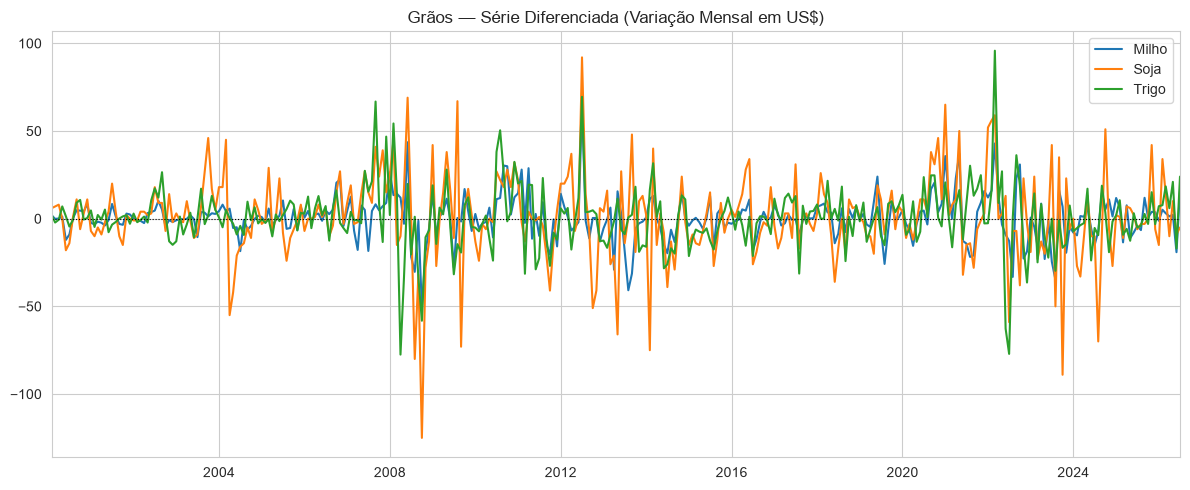

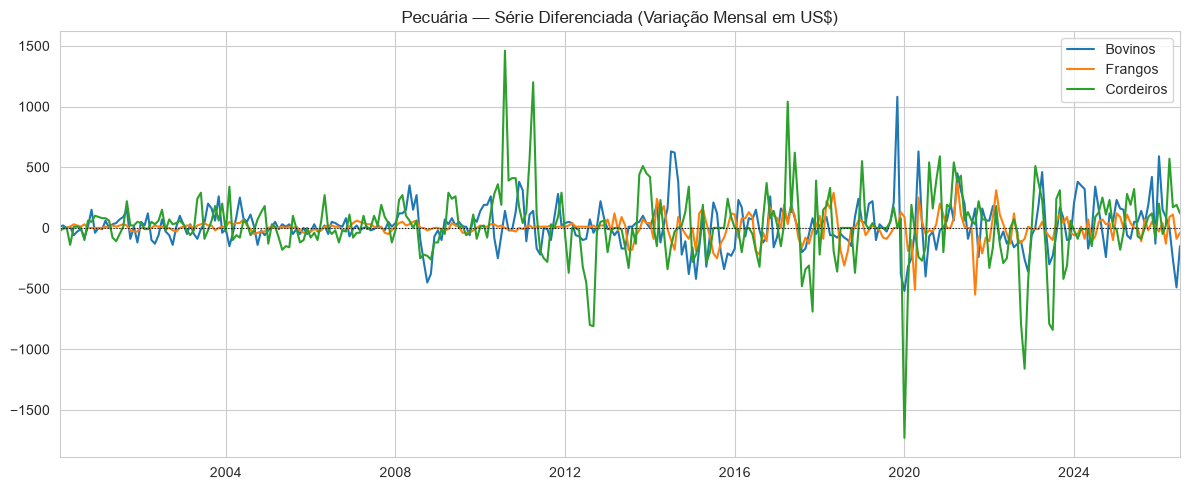

In [32]:
# De forma a analisar a diferenciação após a 1° diferença, vamos plotar um gráfico para melhor entender a diferenciação. 

df_diff = df_commodities.diff().dropna()

# Gráfico 3: diferenciação dos grãos
fig, ax = plt.subplots(figsize=(12, 5))

for col in categoria_graos:
    ax.plot(df_diff.index, df_diff[col], label=col)

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_title("Grãos — Série Diferenciada (Variação Mensal em US$)")
ax.legend()
plt.margins(x=0)
plt.tight_layout()
plt.show()

# Gráfico 4: diferenciação da pecuária
fig, ax = plt.subplots(figsize=(12, 5))
for col in categoria_pecuaria:
    ax.plot(df_diff.index, df_diff[col], label=col)

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_title("Pecuária — Série Diferenciada (Variação Mensal em US$)")
ax.legend()
plt.margins(x=0)
plt.tight_layout()
plt.show()

# Benchmark Preditivo - Random Walk

Para avaliar a real capacidade de predição do modelo ARIMA, precisamos estabelecer um modelo de referência (*benchmark*). Em séries financeiras e de commodities, o padrão ouro para essa linha de base é o modelo de **Random Walk** (Passeio Aleatório).

A premissa do Random Walk é simples, ele assume que a melhor previsão para o preço do próximo mês é **o preço do mês atual**. 

> ##### A Prova de Valor
> Modelos matemáticos complexos, como o ARIMA, só justificam sua utilização na prática se conseguirem superar essa previsão "ingênua". Nossa meta é verificar se o ARIMA consegue enxergar padrões nos dados que reduzam o erro de previsão em relação ao Random Walk.

**Metodologia de Teste (Backtesting):**
* **Divisão dos Dados:** Separamos a linha do tempo cronologicamente, utilizando os primeiros **80% dos dados para Treinamento** (onde o modelo aprende os padrões) e os últimos **20% para Teste** (onde avaliamos a precisão em dados "inéditos").
* **Métrica de Avaliação:** Utilizaremos o **MAPE** (Erro Percentual Absoluto Médio) para colocar o ARIMA e o Random Walk lado a lado e declarar o vencedor.

In [37]:
def benchmark_random_walk(serie, nome, horizonte=12):
    serie = serie.dropna()
    
    if horizonte <= 0 or horizonte >= len(serie):
        raise ValueError("horizonte must be >0 and < length of series")
    
    # Split: fixo de 12 meses de teste, restante é para treino
    train = serie[:-horizonte]
    test = serie[-horizonte:]
    
    # Predição do Random Walk 
    y_true = test.values
    y_pred = np.repeat(train.iloc[-1], horizonte)
    
    # Cálcula metricas
    mae = float(np.mean(np.abs(y_true - y_pred)))
    
    # Sai da divisão por 0 do MAPE
    denom = np.where(y_true == 0, np.finfo(float).eps, y_true)
    mape = float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)
    
    # Usando root_mean_squared_error em vez de deprecated squared parameter
    rmse = float(root_mean_squared_error(y_true, y_pred))
    
    return {
        "Commodity": nome,
        "MAE (Random Walk)": round(mae, 2),
        "RMSE (Random Walk)": round(rmse, 2),
        "MAPE (Random Walk)": round(mape, 2)
    }

In [38]:
resultados_rw = [benchmark_random_walk(df_commodities[col], col) for col in df_commodities.columns]
tabela_rw = pd.DataFrame(resultados_rw)
tabela_rw

,Commodity,MAE (Random Walk),RMSE (Random Walk),MAPE (Random Walk)
0,Milho,13.77,15.40,6.61
1,Soja,35.58,41.80,7.77
2,Trigo,28.96,38.39,10.20
3,Bovinos,860.83,984.04,11.00
4,Frangos,45.83,59.65,2.66
5,Cordeiros,425.83,616.99,5.92


# Rodando o ARIMA

In [1]:
def selecionar_ordem_arima(serie_treino, d_fixo, p_max=3, q_max=3):
    """
    Seleciona a melhor ordem (p, d, q) para o modelo ARIMA com base no AIC.
    
    Parâmetros:
    - serie_treino: Série temporal de treino (pandas Series).
    - d_fixo: Valor fixo de d (diferenciação).
    - p_max: Valor máximo de p a ser testado.
    - q_max: Valor máximo de q a ser testado.
    
    Retorna:
    - Melhor ordem (p, d, q) com o menor AIC.
    """
    best_aic = np.inf
    best_order = None
    
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            try:
                model = ARIMA(serie_treino, order=(p, d_fixo, q))
                model_fit = model.fit()
                aic = model_fit.aic
                
                if aic < best_aic:
                    best_aic = aic
                    best_order = (p, d_fixo, q)
            except Exception as e:
                continue
    
    return best_order

In [2]:
def backteste_arima(serie, nome, d_fixo, horizonte=12, p_max=3, q_max=3):
    """
    Realiza o backteste do modelo ARIMA para uma série temporal.
    
    Parâmetros:
    - serie: Série temporal (pandas Series).
    - nome: Nome da commodity.
    - d_fixo: Valor fixo de d (diferenciação).
    - horizonte: Número de períodos para previsão.
    - p_max: Valor máximo de p a ser testado.
    - q_max: Valor máximo de q a ser testado.
    
    Retorna:
    - Dicionário com métricas de desempenho do modelo ARIMA.
    """
    serie = serie.dropna()
    
    if horizonte <= 0 or horizonte >= len(serie):
        raise ValueError("horizonte must be >0 and < length of series")
    
    # Split: fixo de 12 meses de teste, restante é para treino
    train = serie[:-horizonte]
    test = serie[-horizonte:]
    
    # Seleciona a melhor ordem (p, d, q) com base no AIC
    best_order = selecionar_ordem_arima(train, d_fixo, p_max, q_max)
    
    if best_order is None:
        raise ValueError(f"Não foi possível ajustar um modelo ARIMA para {nome}.")
    
    # Ajusta o modelo ARIMA com a melhor ordem
    model = ARIMA(train, order=best_order)
    model_fit = model.fit()
    
    # Faz previsões
    forecast = model_fit.forecast(steps=horizonte)
    
    # Cálcula métricas
    y_true = test.values
    y_pred = forecast.values
    
    mae = float(np.mean(np.abs(y_true - y_pred)))
    
    # Sai da divisão por 0 do MAPE
    denom = np.where(y_true == 0, np.finfo(float).eps, y_true)
    mape = float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)
    
    rmse = float(root_mean_squared_error(y_true, y_pred))
    
    return {
        "Commodity": nome,
        "Best Order (p,d,q)": best_order,
        "MAE (ARIMA)": round(mae, 2),
        "RMSE (ARIMA)": round(rmse, 2),
        "MAPE (ARIMA)": round(mape, 2)
    }

In [ ]:
resultados_arima = [backteste_arima(df_commodities[col], col, d_fixo=1) for col in df_commodities.columns]
tabela_arima = pd.DataFrame(resultados_arima)
tabela_arima